In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
df = pd.read_csv("../data/india_city_aqi_2015_2023-cleaned_dataset.csv")

In [3]:
# Defining features and target Pollutants and Season
pollutants = ['pm2.5', 'pm10', 'no2', 'so2', 'co', 'o3']
features = pollutants + ['season']
target = 'aqi'

# Use the existing `season` column from CSV and create shadow dummy columns from it
base_cols = pollutants + [target, 'aqi_category']
df_final = df[base_cols].copy()

season_shadow = pd.get_dummies(df['season'], prefix='season', drop_first=True)
df_final = pd.concat([df_final, season_shadow], axis=1)

# Update feature list to include the new dummy columns
X = df_final.drop(columns=['aqi', 'aqi_category'])
y = df_final['aqi']
y_cat = df_final['aqi_category']

In [4]:
# Split the data (80% Training, 20% Testing) with stratification
X_train, X_test, y_train, y_test, cat_train, cat_test = train_test_split (X, y, y_cat, test_size=0.2, stratify=y_cat, random_state=42)

print("Training category counts:")
print(cat_train.value_counts())

print("\nTesting category counts:")
print(cat_test.value_counts())

Training category counts:
aqi_category
Satisfactory    13795
Moderate         9146
Good             3347
Poor                8
Name: count, dtype: int64

Testing category counts:
aqi_category
Satisfactory    3449
Moderate        2287
Good             836
Poor               2
Name: count, dtype: int64


In [5]:
# Scaling of features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [6]:
# Weighted penalties
train_weights = []

# Loop through each row in the training data
for idx in X_train.index:
    category = df.loc[idx, 'aqi_category']
    season = df.loc[idx, 'season']
    
    # Major boosts for Poor due to data scarcity
    if category == 'Poor':
        if season == 'Post-Monsoon': train_weights.append(3000.0)
        elif season == 'Winter': train_weights.append(2000.0)
        elif season == 'Summer': train_weights.append(1000.0)
        else: train_weights.append(500.0) # Monsoon
    elif category == 'Moderate':
        train_weights.append(5.0) # Slight boost for Moderate
    else:
        train_weights.append(1.0) # Normal weight for Good/Satisfactory

In [7]:
model = LinearRegression()
model.fit(X_train_scaled, y_train, sample_weight=train_weights)

# Model Training Complete

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [8]:
# Predict raw numerical AQI values & Convert raw numbers back to AQI Categories
y_pred_num = model.predict(X_test_scaled)

def bin_aqi(value):
    if value <= 50: return 'Good'
    elif value <= 100: return 'Satisfactory'
    elif value <= 200: return 'Moderate'
    else: return 'Poor'

y_pred_category = [bin_aqi(val) for val in y_pred_num]

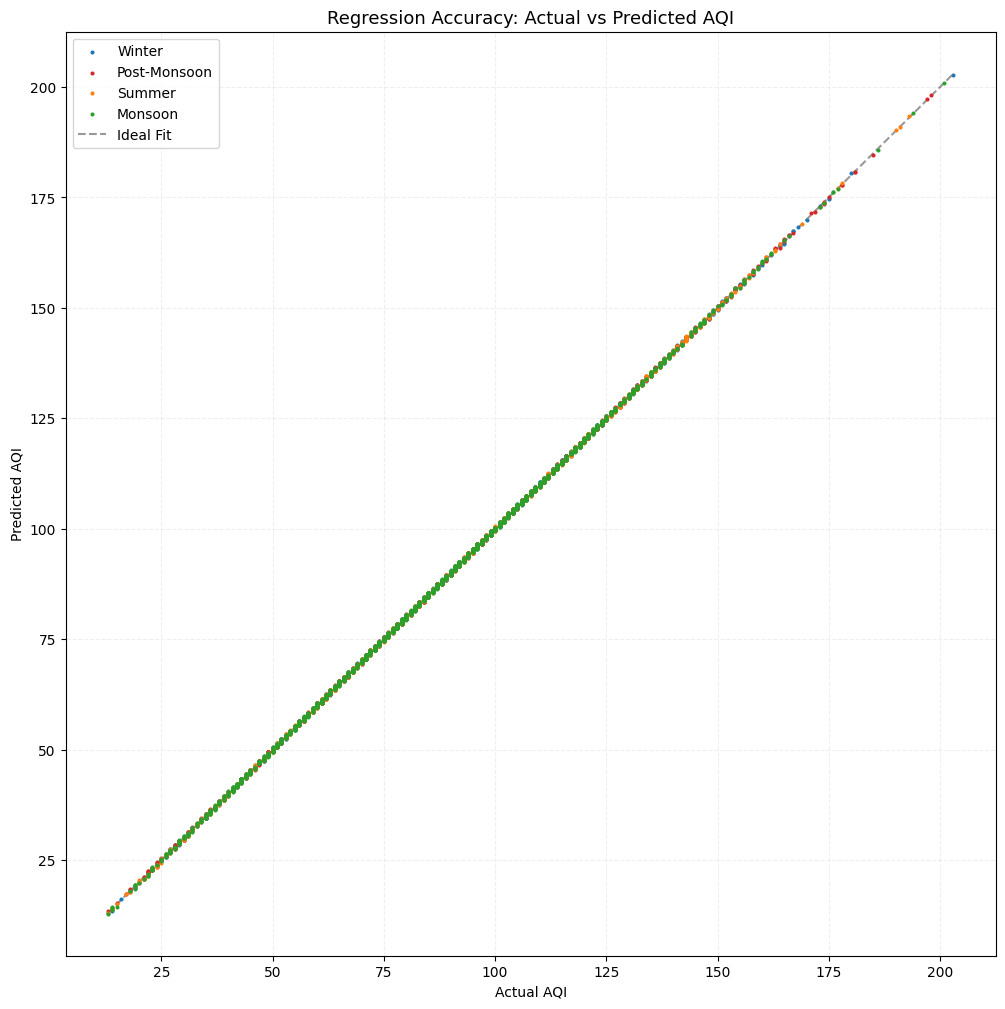

In [9]:
season_labels = np.where(X_test['season_Winter'], 'Winter',np.where(X_test['season_Summer'], 'Summer',np.where(X_test['season_Post-Monsoon'],'Post-Monsoon', 'Monsoon')))

plot_df = pd.DataFrame({'Actual AQI': y_test.values,'Predicted AQI': y_pred_num,'Season': season_labels})

colors = {'Winter': 'tab:blue','Summer': 'tab:orange','Monsoon': 'tab:green','Post-Monsoon': 'tab:red'}

plt.figure(figsize=(12,12))

for season_name in ['Winter', 'Post-Monsoon', 'Summer', 'Monsoon']:
    group = plot_df[plot_df['Season'] == season_name]
    if not group.empty:
        plt.scatter(group['Actual AQI'],group['Predicted AQI'],alpha=1.0,s=15,marker='.',label=season_name,color=colors.get(season_name, 'gray'),zorder=3)

min_val, max_val = plot_df['Actual AQI'].min(), plot_df['Actual AQI'].max()
plt.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.4, label='Ideal Fit', zorder=2)

plt.title('Regression Accuracy: Actual vs Predicted AQI', fontsize=13)
plt.xlabel('Actual AQI')
plt.ylabel('Predicted AQI')
plt.legend()
plt.grid(alpha=0.2, linestyle='--')
plt.show()

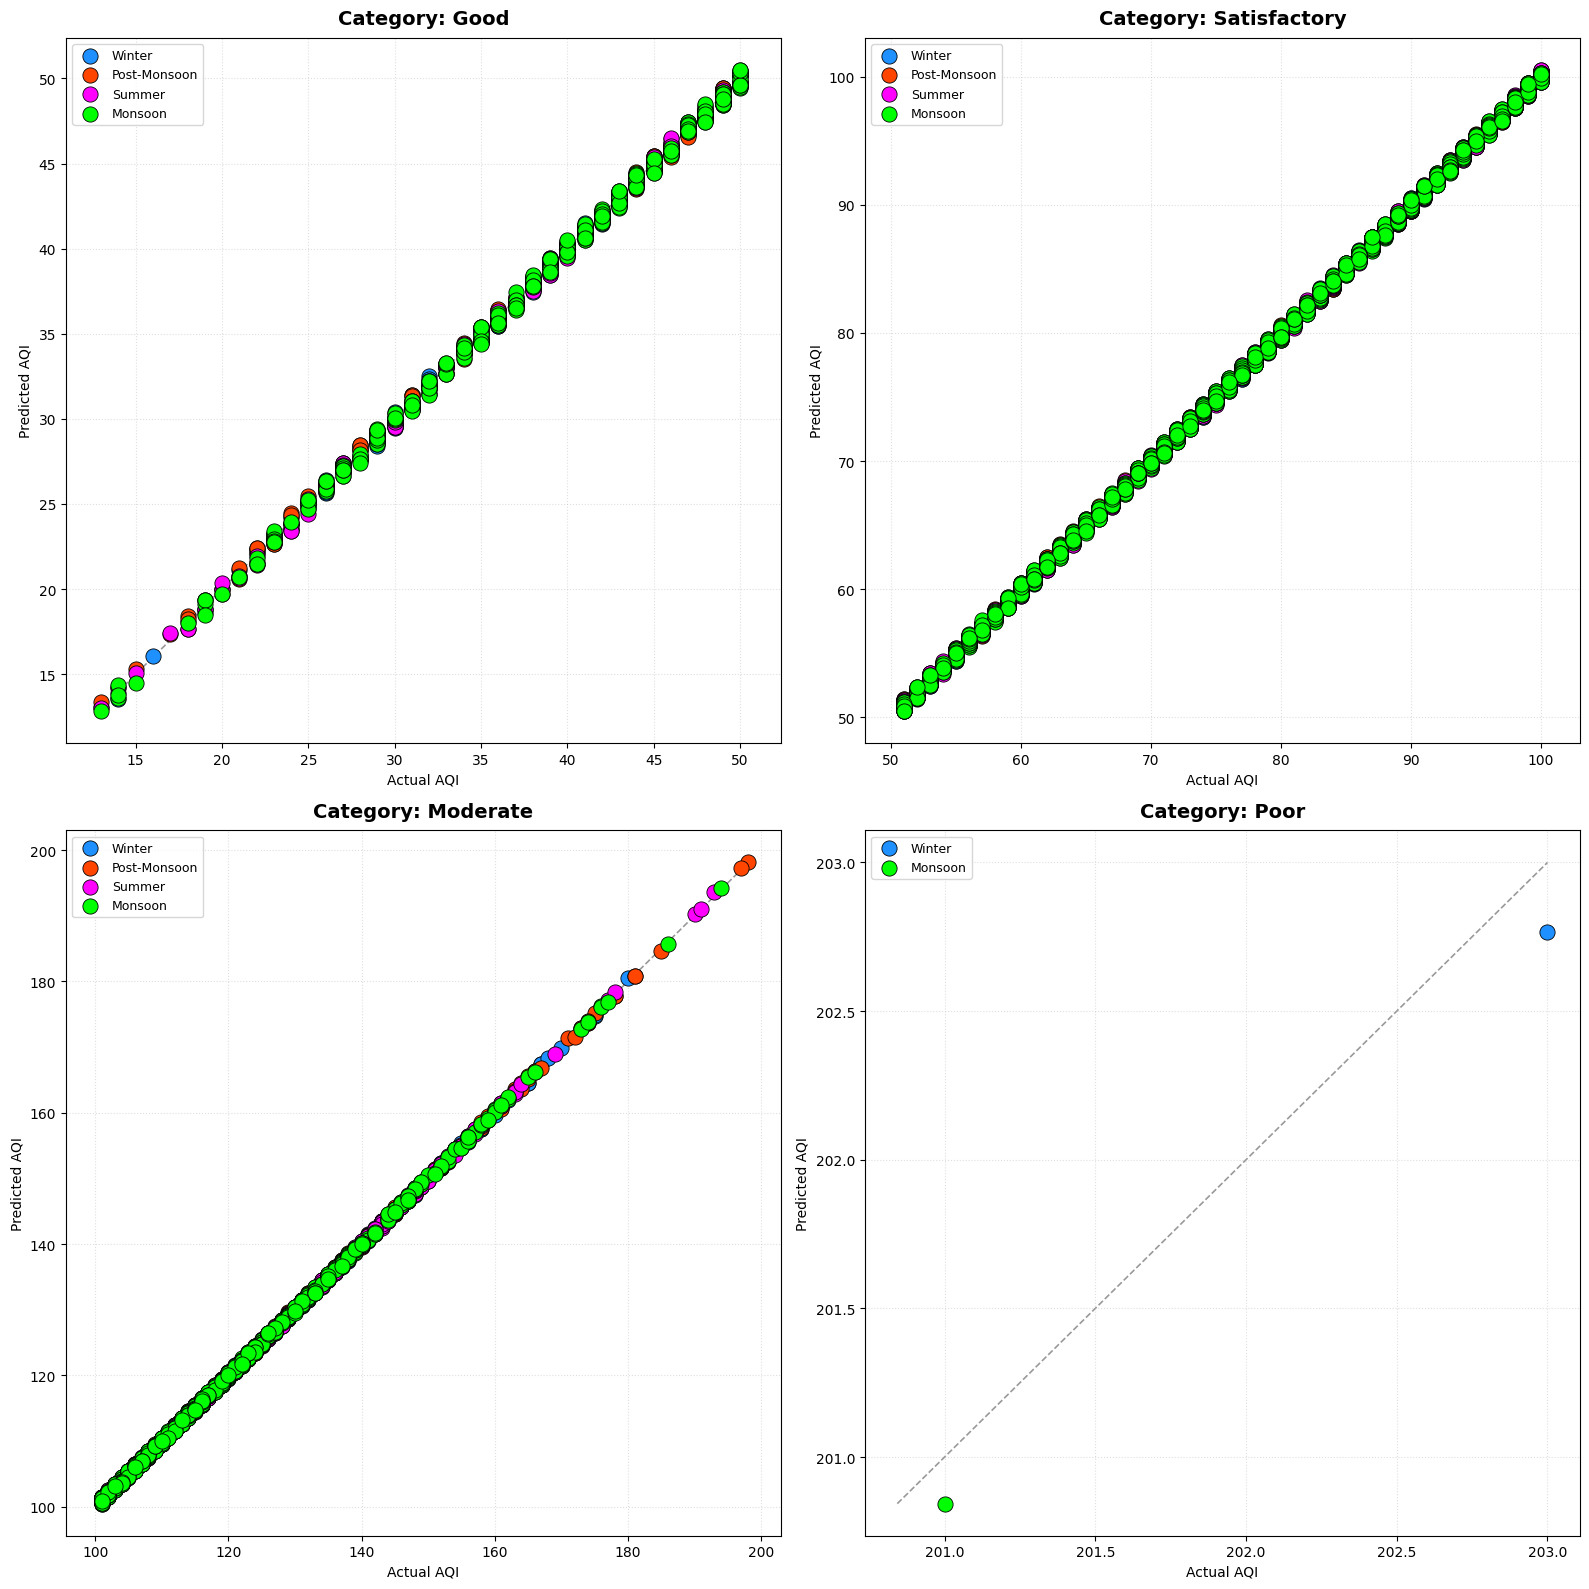

In [10]:
season_labels = np.where(X_test['season_Winter'], 'Winter',np.where(X_test['season_Summer'], 'Summer',np.where(X_test['season_Post-Monsoon'],'Post-Monsoon', 'Monsoon')))

plot_df = pd.DataFrame({'Actual AQI': y_test.values,'Predicted AQI': y_pred_num,'Actual Category': cat_test.values,'Season': season_labels})

season_configs = {'Monsoon':      {'color': '#00FF00', 'zorder': 5},'Summer':       {'color': '#FF00FF', 'zorder': 4},'Post-Monsoon': {'color': '#FF4500', 'zorder': 3},'Winter':       {'color': '#1E90FF', 'zorder': 2}}

cat_labels = ['Good', 'Satisfactory', 'Moderate', 'Poor']

plt.figure(figsize=(16, 16))

for i, cat in enumerate(cat_labels, 1):
    ax = plt.subplot(2, 2, i)
    cat_df = plot_df[plot_df['Actual Category'] == cat]

    for season_name in ['Winter', 'Post-Monsoon', 'Summer', 'Monsoon']:
        group = cat_df[cat_df['Season'] == season_name]
        if not group.empty:
            config = season_configs[season_name]
            ax.scatter(group['Actual AQI'],group['Predicted AQI'],alpha=1.0, s=120,label=season_name,color=config['color'],zorder=config['zorder'],edgecolors='black', linewidths=0.6)

    ax.legend(fontsize=10, loc='upper left', markerscale=1.5, frameon=True)

    if not cat_df.empty:
        all_vals = pd.concat([cat_df['Actual AQI'], cat_df['Predicted AQI']])
        min_v, max_v = all_vals.min(), all_vals.max()
        ax.plot([min_v, max_v], [min_v, max_v], 'k--', alpha=0.4, linewidth=1.2, zorder=1)

    ax.set_title(f'Category: {cat}', fontsize=14, fontweight='bold', pad=10)
    ax.set_xlabel('Actual AQI')
    ax.set_ylabel('Predicted AQI')
    ax.grid(True, linestyle=':', alpha=0.4, zorder=0)

    ax.legend(fontsize=9, loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

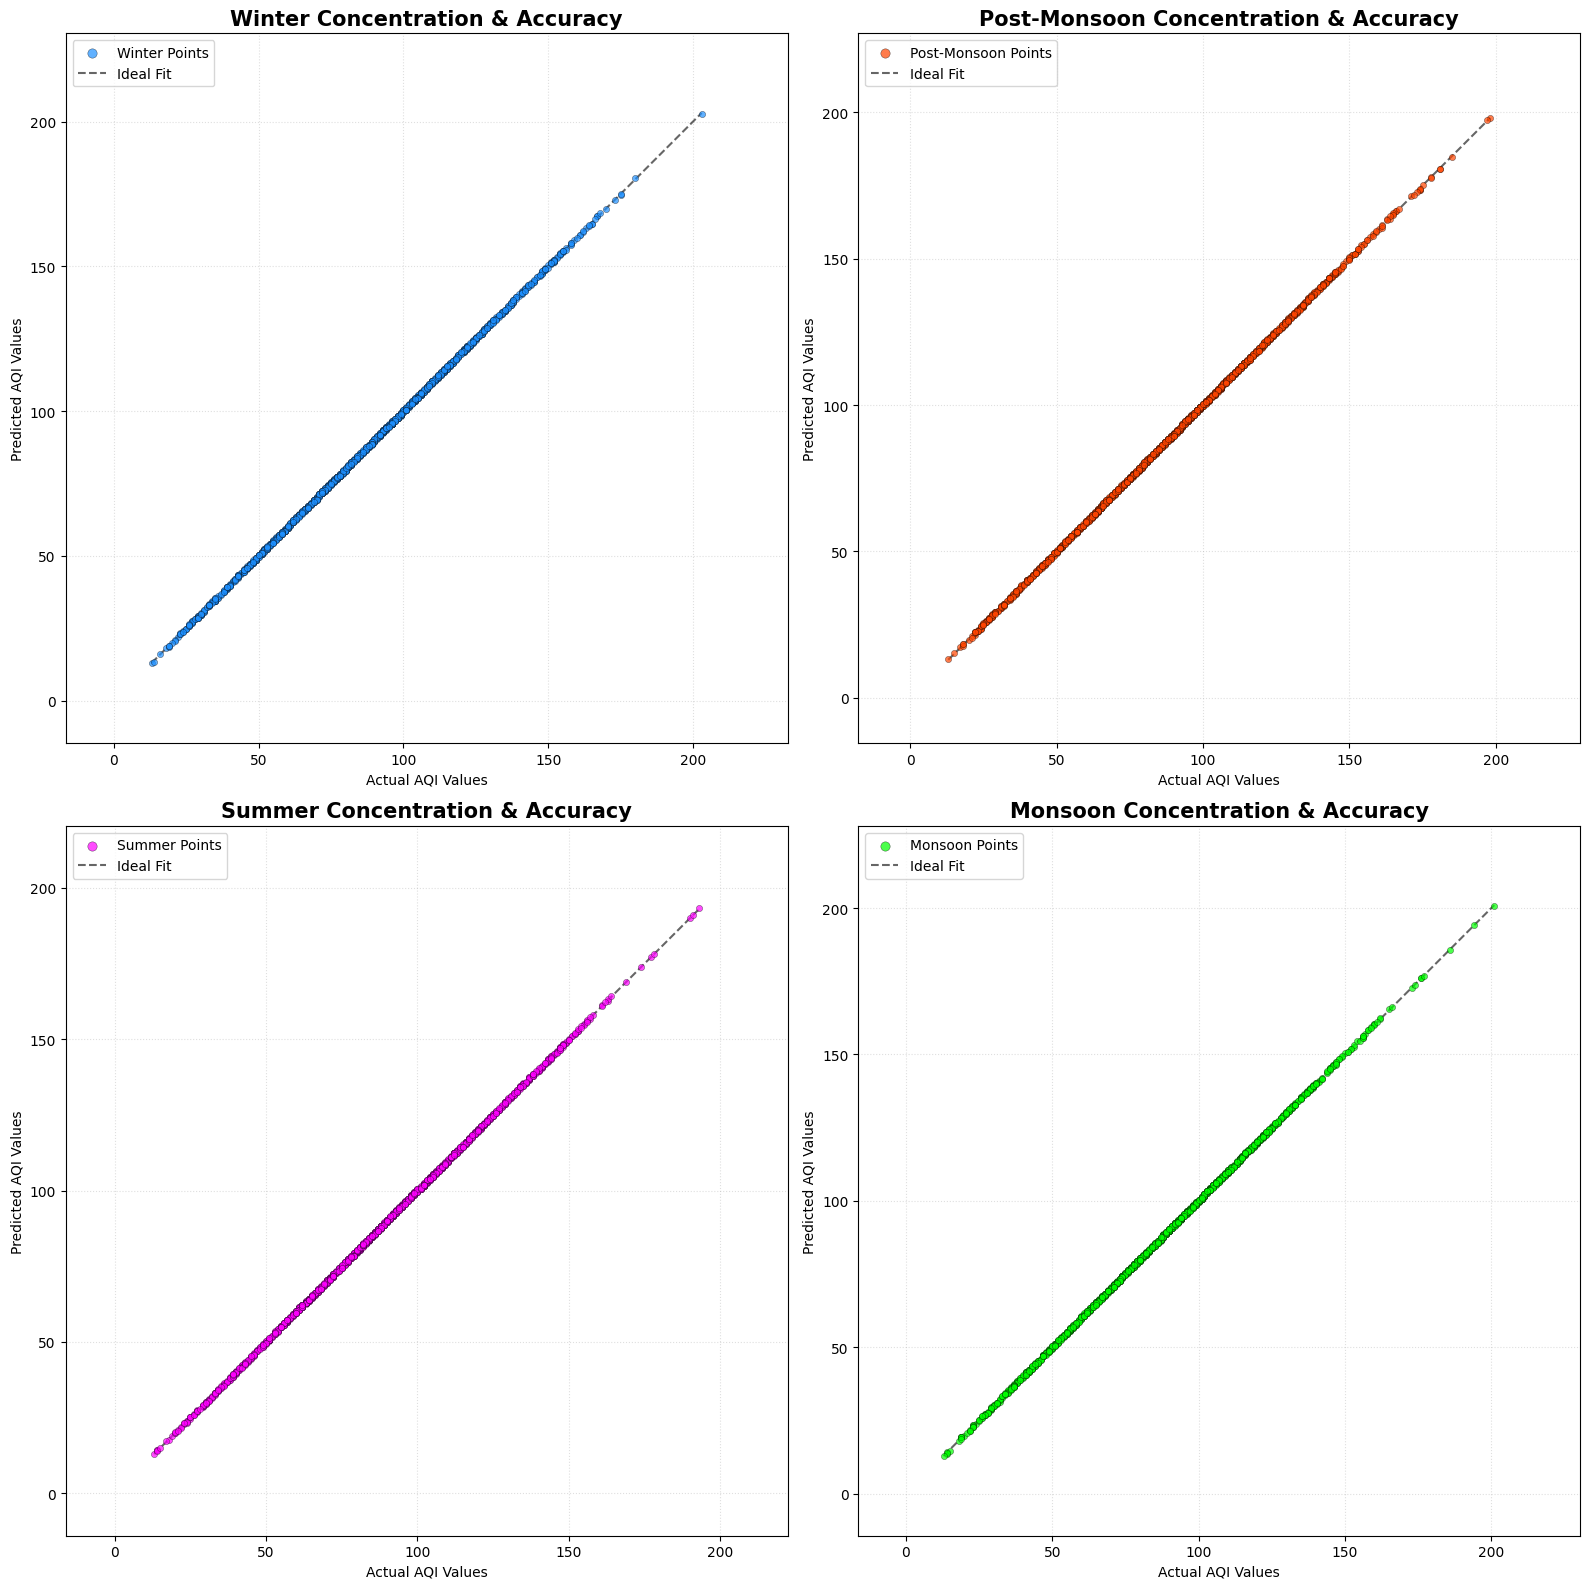

In [11]:
import seaborn as sns

season_labels = np.where(X_test['season_Winter'], 'Winter',np.where(X_test['season_Summer'], 'Summer',np.where(X_test['season_Post-Monsoon'],'Post-Monsoon', 'Monsoon')))

plot_df = pd.DataFrame({'Actual AQI': y_test.values,'Predicted AQI': y_pred_num,'Season': season_labels})

seasons = ['Winter', 'Post-Monsoon', 'Summer', 'Monsoon']
season_colors = {'Winter': '#1E90FF', 'Post-Monsoon': '#FF4500', 'Summer': '#FF00FF', 'Monsoon': '#00FF00'}

plt.figure(figsize=(16, 16))

for i, season in enumerate(seasons, 1):
    ax = plt.subplot(2, 2, i)
    season_df = plot_df[plot_df['Season'] == season]
    
    if not season_df.empty:
        sns.kdeplot(data=season_df, x='Actual AQI', y='Predicted AQI', ax=ax, fill=True, alpha=0.3, thresh=0.05, levels=10, cmap="Greys", zorder=1)
        
        ax.scatter(season_df['Actual AQI'], season_df['Predicted AQI'],alpha=0.7, s=80, marker='.',color=season_colors[season], edgecolors='black',linewidths=0.3, zorder=3, label=f'{season} Points')

        min_v = min(season_df['Actual AQI'].min(), season_df['Predicted AQI'].min())
        max_v = max(season_df['Actual AQI'].max(), season_df['Predicted AQI'].max())
        ax.plot([min_v, max_v], [min_v, max_v], 'k--', alpha=0.6, linewidth=1.5, zorder=2, label='Ideal Fit')
        
        ax.set_title(f'{season} Concentration & Accuracy', fontsize=15, fontweight='bold')
        ax.set_xlabel('Actual AQI Values')
        ax.set_ylabel('Predicted AQI Values')
        ax.set_aspect('equal', adjustable='datalim')
        ax.grid(True, linestyle=':', alpha=0.4, zorder=0)
        ax.legend(loc='upper left', markerscale=1.5)

plt.tight_layout()
plt.show()

In [12]:
print(classification_report(cat_test, y_pred_category))

              precision    recall  f1-score   support

        Good       1.00      0.98      0.99       836
    Moderate       0.99      1.00      0.99      2287
        Poor       1.00      1.00      1.00         2
Satisfactory       1.00      0.99      0.99      3449

    accuracy                           0.99      6574
   macro avg       1.00      0.99      0.99      6574
weighted avg       0.99      0.99      0.99      6574



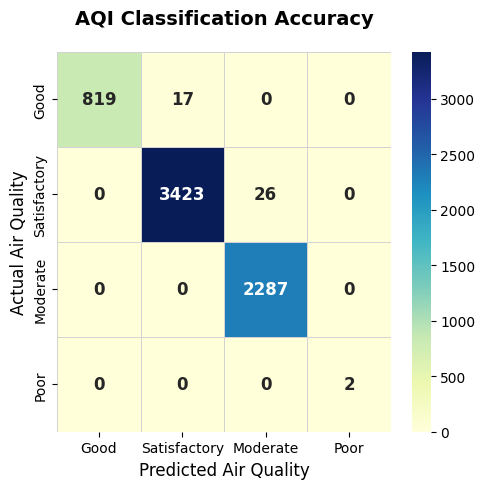

In [13]:
plt.figure(figsize=(5,5))
cat_labels = ['Good', 'Satisfactory', 'Moderate', 'Poor']
cm = confusion_matrix(cat_test, y_pred_category, labels=cat_labels)

sns.heatmap(cm,annot=True,fmt='d',cmap='YlGnBu',xticklabels=cat_labels,yticklabels=cat_labels,cbar=True,linewidths=.5,linecolor='lightgrey',annot_kws={"size": 12, "weight": "bold"})

plt.title('AQI Classification Accuracy', fontsize=14, pad=20, fontweight='bold')
plt.xlabel('Predicted Air Quality', fontsize=12)
plt.ylabel('Actual Air Quality', fontsize=12)

plt.tight_layout()
plt.show()

C:\Users\MUKUND PRASAD\AppData\Local\Temp\ipykernel_24372\1242334516.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Weight', y='Feature', data=coef_df, palette='viridis')


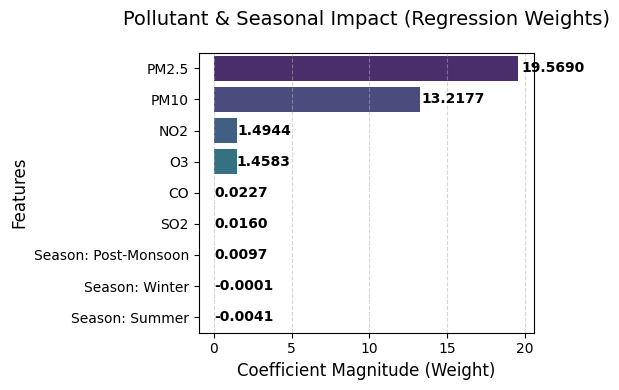

In [14]:
plt.figure(figsize=(6,4))

label_map = {'pm2.5': 'PM2.5','pm10': 'PM10','no2': 'NO2','so2': 'SO2','co': 'CO','o3': 'O3','season_Post-Monsoon': 'Season: Post-Monsoon','season_Summer': 'Season: Summer','season_Winter': 'Season: Winter'}
pretty_labels = [label_map.get(col, col) for col in X.columns]

coef_df = pd.DataFrame({'Feature': pretty_labels, 'Weight': model.coef_})
coef_df = coef_df.sort_values(by='Weight', ascending=False)

target_features = list(label_map.values())
coef_df = coef_df[coef_df['Feature'].isin(target_features)]

ax = sns.barplot(x='Weight', y='Feature', data=coef_df, palette='viridis')

for i, p in enumerate(ax.patches):
    width = p.get_width()
    ax.text(width + (width * 0.01),p.get_y() + p.get_height() / 2,f'{width:.4f}', va='center',fontweight='bold')

plt.title('Pollutant & Seasonal Impact (Regression Weights)', fontsize=14, pad=20)
plt.xlabel('Coefficient Magnitude (Weight)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()